# Apprentissage supervisé — student-por (k=3 et k=4)

Même démarche que `apprentissage.ipynb` appliquée au dataset portugais.
Pour chaque valeur de k :
1. Génération des labels K-means (24 composantes PCA, 80.9% variance)
2. Sélection des features par ANOVA (η²)
3. Vérification de l'homoscédasticité
4. KNN — validation croisée 10-fold
5. LDA (shrinkage) + QDA (reg_param) — comparaison + matrices de confusion
6. Projection dans l'espace LDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import f_oneway

import warnings
warnings.filterwarnings('ignore')


## 1. Chargement et encodage (42 variables)

In [2]:
student_por = pd.read_csv("donnees/student-por.csv")

num_cols  = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
             'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
             'absences', 'G1', 'G2', 'G3']
bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher',
             'nursery', 'internet', 'romantic']
cat_cols  = ['school', 'sex', 'address', 'famsize', 'Pstatus',
             'Mjob', 'Fjob', 'reason', 'guardian']

bool_df = student_por[bool_cols].apply(lambda c: (c == 'yes').astype(int))
enc = OneHotEncoder(sparse_output=False, drop='first')
cat_enc = pd.DataFrame(
    enc.fit_transform(student_por[cat_cols]),
    columns=enc.get_feature_names_out(cat_cols)
)
df_full = pd.concat([
    student_por[num_cols].reset_index(drop=True),
    bool_df.reset_index(drop=True),
    cat_enc.reset_index(drop=True)
], axis=1).dropna()

X_full = StandardScaler().fit_transform(df_full)
print(f"Dataset : {df_full.shape}  ({df_full.shape[1]} variables)")


Dataset : (649, 42)  (42 variables)


## 2. ACP — réduction (seuil 80% de variance)

In [3]:
pca_full = PCA()
pca_full.fit(X_full)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n_80 = np.searchsorted(cum, 0.80) + 1
print(f"Composantes pour 80% de variance : {n_80}  ({cum[n_80-1]*100:.1f}%)")

pca_red = PCA(n_components=n_80, random_state=42)
X_pca   = pca_red.fit_transform(X_full)

cv = KFold(n_splits=10, shuffle=True, random_state=42)


Composantes pour 80% de variance : 24  (80.9%)


---
## k=3 — Trois archétypes

| Cluster | Archétype | n |
|---------|-----------|---|
| 0 | Décrochage scolaire — le plus vieux, le plus festif, peu d'ambition (`higher`=70%) | 202 |
| 1 | Hustlers — travailleur, notes correctes, 74% femmes, capital parental modeste | 250 |
| 2 | Excellent en Famille — Medu/Fedu élevés, bonnes notes, `higher`=100% | 197 |

### 1. Labels K-means k=3

In [4]:
labels3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_pca)
for c, n in pd.Series(labels3).value_counts().sort_index().items():
    print(f"  Cluster {c} : {n} individus")


  Cluster 0 : 202 individus
  Cluster 1 : 250 individus
  Cluster 2 : 197 individus


### 2. ANOVA — sélection des features

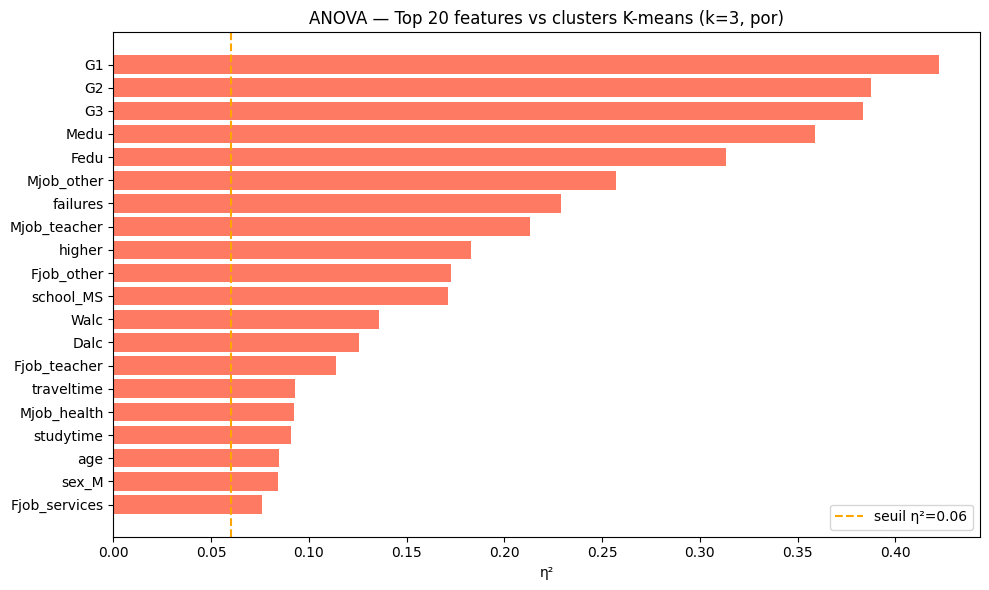

Features retenues (23) : ['G1', 'G2', 'G3', 'Medu', 'Fedu', 'Mjob_other', 'failures', 'Mjob_teacher', 'higher', 'Fjob_other', 'school_MS', 'Walc', 'Dalc', 'Fjob_teacher', 'traveltime', 'Mjob_health', 'studytime', 'age', 'sex_M', 'Fjob_services', 'address_U', 'Mjob_services', 'internet']


In [5]:
def anova_select(df, labels, k, threshold=0.06):
    results = []
    for feat in df.columns:
        groups = [df[feat].values[labels == c] for c in range(k)]
        ss_between = sum(len(g) * (g.mean() - df[feat].mean())**2 for g in groups)
        ss_total   = sum((df[feat].values - df[feat].mean())**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        results.append({'feature': feat, 'eta2': eta2})
    df_res = pd.DataFrame(results).sort_values('eta2', ascending=False)
    top = df_res[df_res['eta2'] > threshold]['feature'].tolist()
    return df_res, top

df_anova3, top3 = anova_select(df_full, labels3, 3)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = df_anova3.head(20)
colors = ['tomato' if f in top3 else 'lightgray' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['eta2'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.06, color='orange', linestyle='--', label='seuil η²=0.06')
ax.set_xlabel("η²")
ax.set_title("ANOVA — Top 20 features vs clusters K-means (k=3, por)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Features retenues ({len(top3)}) : {top3}")
X3 = StandardScaler().fit_transform(df_full[top3])
y3 = labels3


### 3. Homoscédasticité

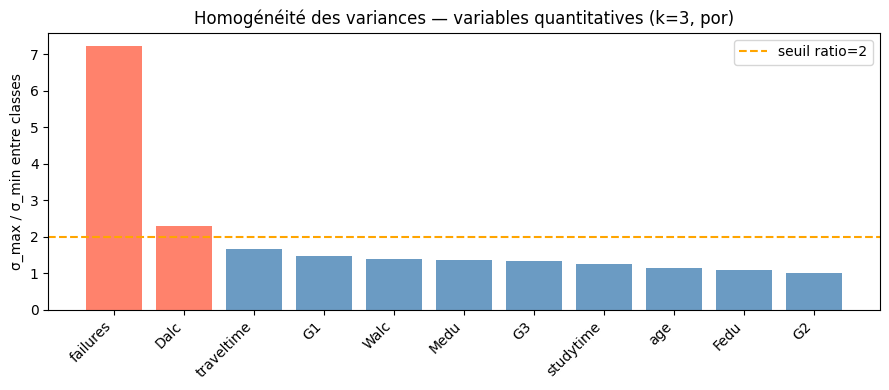

Ratios quantitatifs : {'failures': 7.23, 'Dalc': 2.3, 'traveltime': 1.66, 'G1': 1.46, 'Walc': 1.38, 'Medu': 1.37, 'G3': 1.34, 'studytime': 1.25, 'age': 1.14, 'Fedu': 1.08, 'G2': 1.01}
Features avec ratio > 2 : ['failures', 'Dalc']
Variables binaires (ratio non calculable) : ['Mjob_other', 'Mjob_teacher', 'higher', 'Fjob_other', 'school_MS', 'Fjob_teacher', 'Mjob_health', 'sex_M', 'Fjob_services', 'address_U', 'Mjob_services', 'internet']


In [6]:
X3_df = pd.DataFrame(X3, columns=top3)
X3_df['cluster'] = y3
std3     = X3_df.groupby('cluster')[top3].std()
binary3  = [f for f in top3 if X3_df[f].nunique() <= 2]
quant3   = [f for f in top3 if f not in binary3]
ratio3   = (std3[quant3].max() / std3[quant3].min()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ratio3.index, ratio3.values,
       color=['tomato' if r > 2 else 'steelblue' for r in ratio3.values], alpha=0.8)
ax.axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
ax.set_xticklabels(ratio3.index, rotation=45, ha='right')
ax.set_ylabel('σ_max / σ_min entre classes')
ax.set_title('Homogénéité des variances — variables quantitatives (k=3, por)')
ax.legend()
plt.tight_layout()
plt.show()

print("Ratios quantitatifs :", ratio3.round(2).to_dict())
flagged = ratio3[ratio3 > 2]
if len(flagged):
    print(f"Features avec ratio > 2 : {list(flagged.index)}")
else:
    print("Toutes les variables quantitatives ont un ratio < 2.")
print(f"Variables binaires (ratio non calculable) : {binary3}")


### 4. KNN — Validation croisée 10-fold

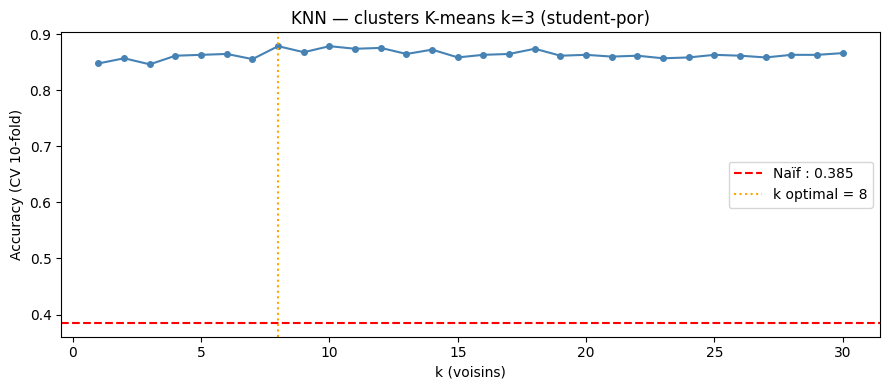

k optimal : 8  →  accuracy = 0.878
Référence naïve : 0.385


In [7]:
k_vals  = range(1, 31)
scores3 = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X3, y3, cv=cv, scoring='accuracy').mean()
           for k in k_vals]
best_k3 = list(k_vals)[np.argmax(scores3)]
naive3  = pd.Series(y3).value_counts(normalize=True).max()

plt.figure(figsize=(9, 4))
plt.plot(k_vals, scores3, 'o-', color='steelblue', markersize=4)
plt.axhline(naive3, color='red', linestyle='--', label=f'Naïf : {naive3:.3f}')
plt.axvline(best_k3, color='orange', linestyle=':', label=f'k optimal = {best_k3}')
plt.xlabel('k (voisins)'); plt.ylabel('Accuracy (CV 10-fold)')
plt.title('KNN — clusters K-means k=3 (student-por)')
plt.legend(); plt.tight_layout(); plt.show()

print(f"k optimal : {best_k3}  →  accuracy = {max(scores3):.3f}")
print(f"Référence naïve : {naive3:.3f}")


### 5. LDA + QDA

LDA (shrinkage='auto') : 0.928 ± 0.046
QDA (reg_param=0.1)   : 0.872 ± 0.067
Variance LDA : LD1=120.2%  LD2=65.0%


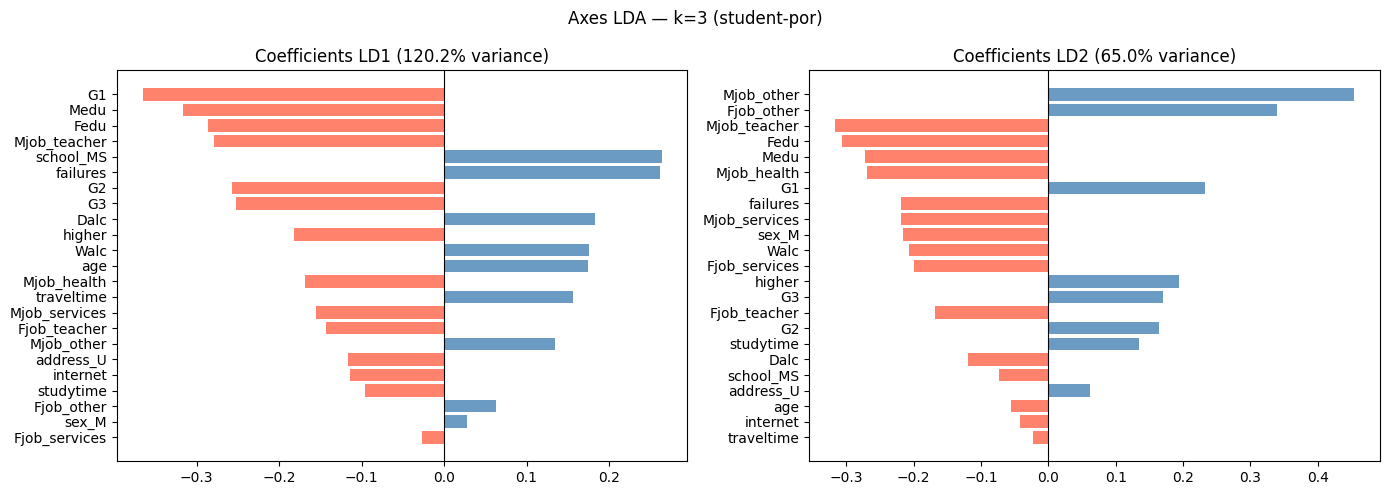

In [8]:
lda3 = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
lda3_scores = cross_val_score(lda3, X3, y3, cv=cv, scoring='accuracy')
lda3.fit(X3, y3)
var3 = lda3.explained_variance_ratio_

qda3 = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda3_scores = cross_val_score(qda3, X3, y3, cv=cv, scoring='accuracy')
qda3.fit(X3, y3)

print(f"LDA (shrinkage='auto') : {lda3_scores.mean():.3f} ± {lda3_scores.std():.3f}")
print(f"QDA (reg_param=0.1)   : {qda3_scores.mean():.3f} ± {qda3_scores.std():.3f}")
print(f"Variance LDA : LD1={var3[0]*100:.1f}%  LD2={var3[1]*100:.1f}%")

coef3 = pd.DataFrame(lda3.scalings_[:, :2], index=top3, columns=['LD1', 'LD2'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, ax in enumerate(axes):
    col = f'LD{i+1}'
    data = coef3[col].sort_values(key=abs, ascending=True)
    colors = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coefficients {col} ({var3[i]*100:.1f}% variance)')
plt.suptitle('Axes LDA — k=3 (student-por)', fontsize=12)
plt.tight_layout(); plt.show()


### 6. Comparaison + matrices de confusion

=== Comparaison k=3 (por) ===
Naïf                  : 0.385
KNN (k= 8)          : 0.878 ± 0.057
LDA (shrinkage='auto'): 0.928 ± 0.046
QDA (reg_param=0.1)   : 0.872 ± 0.067


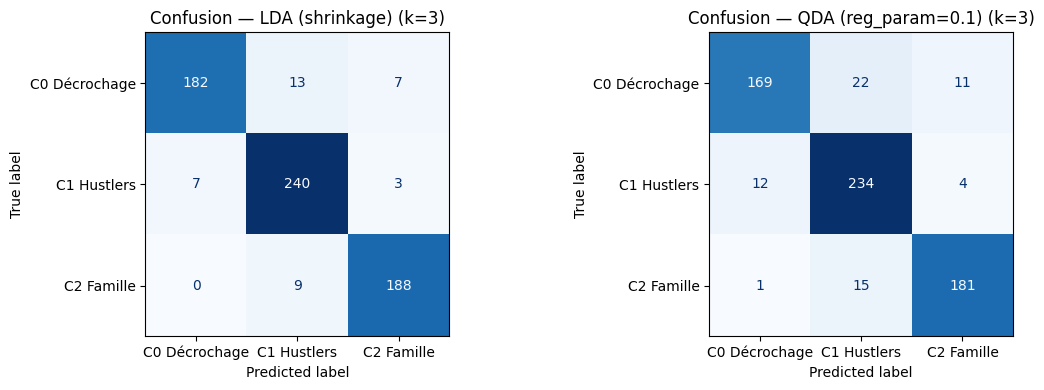

In [9]:
knn3_scores = cross_val_score(KNeighborsClassifier(n_neighbors=best_k3), X3, y3, cv=cv, scoring='accuracy')
labels_short3 = ['C0 Décrochage', 'C1 Hustlers', 'C2 Famille']

print("=== Comparaison k=3 (por) ===")
print(f"Naïf                  : {naive3:.3f}")
print(f"KNN (k={best_k3:2d})          : {knn3_scores.mean():.3f} ± {knn3_scores.std():.3f}")
print(f"LDA (shrinkage='auto'): {lda3_scores.mean():.3f} ± {lda3_scores.std():.3f}")
print(f"QDA (reg_param=0.1)   : {qda3_scores.mean():.3f} ± {qda3_scores.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model, title) in zip(axes, [(lda3, 'LDA (shrinkage)'), (qda3, 'QDA (reg_param=0.1)')]):
    cm = confusion_matrix(y3, model.predict(X3))
    ConfusionMatrixDisplay(cm, display_labels=labels_short3).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — {title} (k=3)')
plt.tight_layout(); plt.show()


### 7. Projection LDA

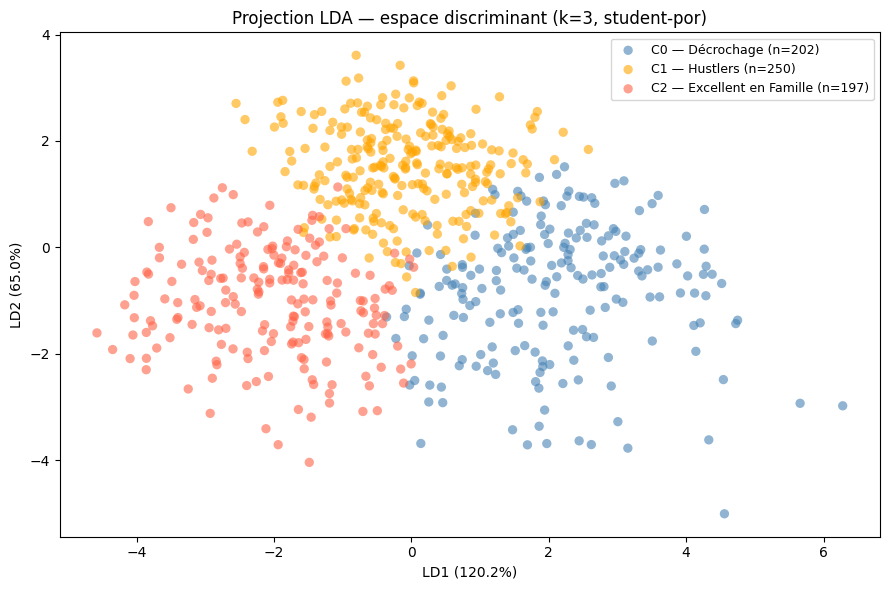

In [10]:
X3_lda  = lda3.transform(X3)
palette = ['steelblue', 'orange', 'tomato']
names3  = ['Décrochage', 'Hustlers', 'Excellent en Famille']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(3):
    mask = y3 == c
    ax.scatter(X3_lda[mask, 0], X3_lda[mask, 1],
               c=palette[c], label=f'C{c} — {names3[c]} (n={mask.sum()})',
               alpha=0.6, s=45, edgecolors='none')
ax.set_xlabel(f'LD1 ({var3[0]*100:.1f}%)')
ax.set_ylabel(f'LD2 ({var3[1]*100:.1f}%)')
ax.set_title('Projection LDA — espace discriminant (k=3, student-por)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


---
## k=4 — Quatre archétypes (subdivision de l'Excellence)

| Cluster | Archétype | n |
|---------|-----------|---|
| 0 | Élite par héritage — Medu/Fedu max, quasi pas de cours payants, légèrement masculin | 80 |
| 1 | Décrochage — inchangé depuis k=3, notes les plus basses, `higher`=68% | 190 |
| 2 | Excellence par soutien actif — famsup élevé, internet=95%, 60% femmes | 154 |
| 3 | Hustlers — travailleur, 74% femmes, réussite sans capital héréditaire | 225 |

### 1. Labels K-means k=4

In [11]:
labels4 = KMeans(n_clusters=4, n_init=50, random_state=42).fit_predict(X_pca)
for c, n in pd.Series(labels4).value_counts().sort_index().items():
    print(f"  Cluster {c} : {n} individus")


  Cluster 0 : 80 individus
  Cluster 1 : 190 individus
  Cluster 2 : 154 individus
  Cluster 3 : 225 individus


### 2. ANOVA — sélection des features

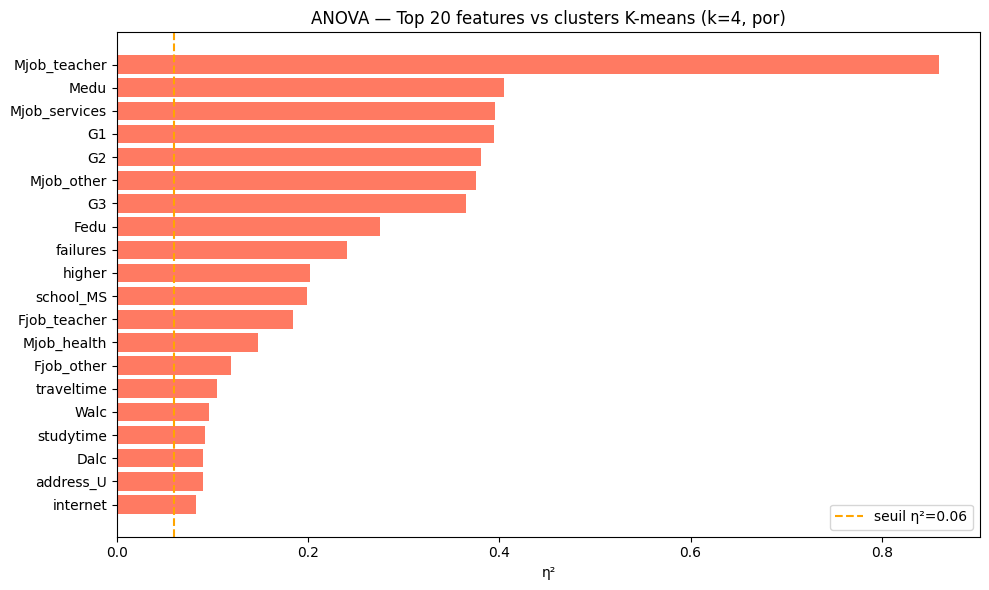

Features retenues (22) : ['Mjob_teacher', 'Medu', 'Mjob_services', 'G1', 'G2', 'Mjob_other', 'G3', 'Fedu', 'failures', 'higher', 'school_MS', 'Fjob_teacher', 'Mjob_health', 'Fjob_other', 'traveltime', 'Walc', 'studytime', 'Dalc', 'address_U', 'internet', 'age', 'sex_M']


In [12]:
df_anova4, top4 = anova_select(df_full, labels4, 4)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = df_anova4.head(20)
colors = ['tomato' if f in top4 else 'lightgray' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['eta2'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.06, color='orange', linestyle='--', label='seuil η²=0.06')
ax.set_xlabel("η²")
ax.set_title("ANOVA — Top 20 features vs clusters K-means (k=4, por)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Features retenues ({len(top4)}) : {top4}")
X4 = StandardScaler().fit_transform(df_full[top4])
y4 = labels4


### 3. Homoscédasticité

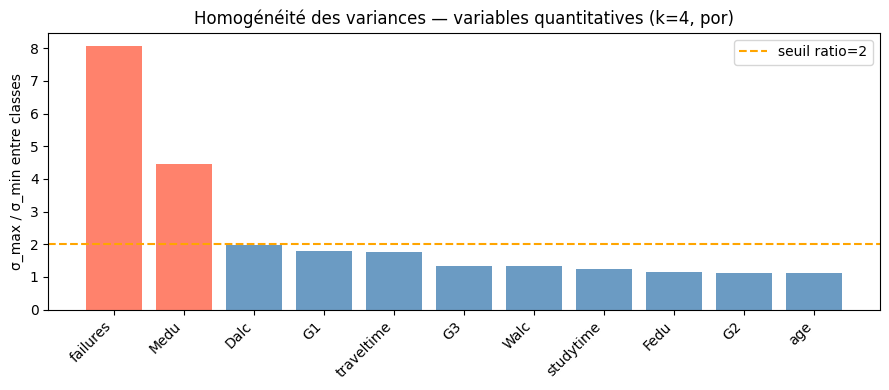

Ratios quantitatifs : {'failures': 8.07, 'Medu': 4.47, 'Dalc': 1.96, 'G1': 1.79, 'traveltime': 1.76, 'G3': 1.35, 'Walc': 1.32, 'studytime': 1.25, 'Fedu': 1.16, 'G2': 1.12, 'age': 1.12}
Features avec ratio > 2 : ['failures', 'Medu']
Variables binaires (ratio non calculable) : ['Mjob_teacher', 'Mjob_services', 'Mjob_other', 'higher', 'school_MS', 'Fjob_teacher', 'Mjob_health', 'Fjob_other', 'address_U', 'internet', 'sex_M']


In [13]:
X4_df = pd.DataFrame(X4, columns=top4)
X4_df['cluster'] = y4
std4    = X4_df.groupby('cluster')[top4].std()
binary4 = [f for f in top4 if X4_df[f].nunique() <= 2]
quant4  = [f for f in top4 if f not in binary4]
ratio4  = (std4[quant4].max() / std4[quant4].min()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ratio4.index, ratio4.values,
       color=['tomato' if r > 2 else 'steelblue' for r in ratio4.values], alpha=0.8)
ax.axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
ax.set_xticklabels(ratio4.index, rotation=45, ha='right')
ax.set_ylabel('σ_max / σ_min entre classes'); ax.legend()
ax.set_title('Homogénéité des variances — variables quantitatives (k=4, por)')
plt.tight_layout(); plt.show()

print("Ratios quantitatifs :", ratio4.round(2).to_dict())
flagged = ratio4[ratio4 > 2]
if len(flagged):
    print(f"Features avec ratio > 2 : {list(flagged.index)}")
else:
    print("Toutes les variables quantitatives ont un ratio < 2.")
print(f"Variables binaires (ratio non calculable) : {binary4}")


### 4. KNN — Validation croisée 10-fold

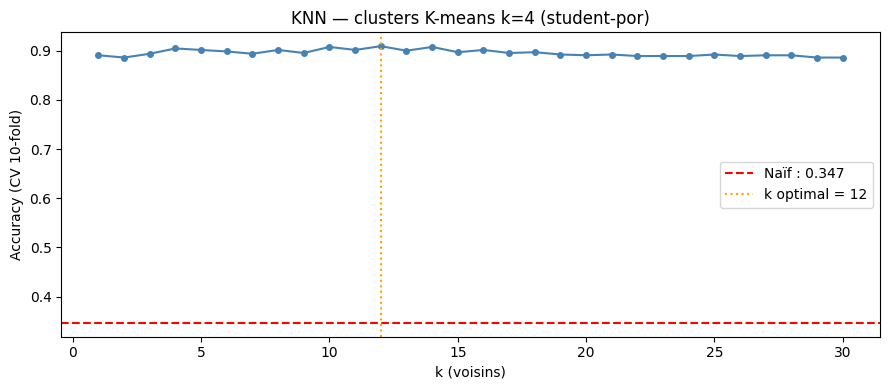

k optimal : 12  →  accuracy = 0.909
Référence naïve : 0.347


In [14]:
k_vals  = range(1, 31)
scores4 = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X4, y4, cv=cv, scoring='accuracy').mean()
           for k in k_vals]
best_k4 = list(k_vals)[np.argmax(scores4)]
naive4  = pd.Series(y4).value_counts(normalize=True).max()

plt.figure(figsize=(9, 4))
plt.plot(k_vals, scores4, 'o-', color='steelblue', markersize=4)
plt.axhline(naive4, color='red', linestyle='--', label=f'Naïf : {naive4:.3f}')
plt.axvline(best_k4, color='orange', linestyle=':', label=f'k optimal = {best_k4}')
plt.xlabel('k (voisins)'); plt.ylabel('Accuracy (CV 10-fold)')
plt.title('KNN — clusters K-means k=4 (student-por)')
plt.legend(); plt.tight_layout(); plt.show()

print(f"k optimal : {best_k4}  →  accuracy = {max(scores4):.3f}")
print(f"Référence naïve : {naive4:.3f}")


### 5. LDA + QDA

LDA (shrinkage='auto') : 0.906 ± 0.022
QDA (reg_param=0.1)   : 0.872 ± 0.033
Variance LDA : LD1=64.3%  LD2=36.1%  LD3=26.4%


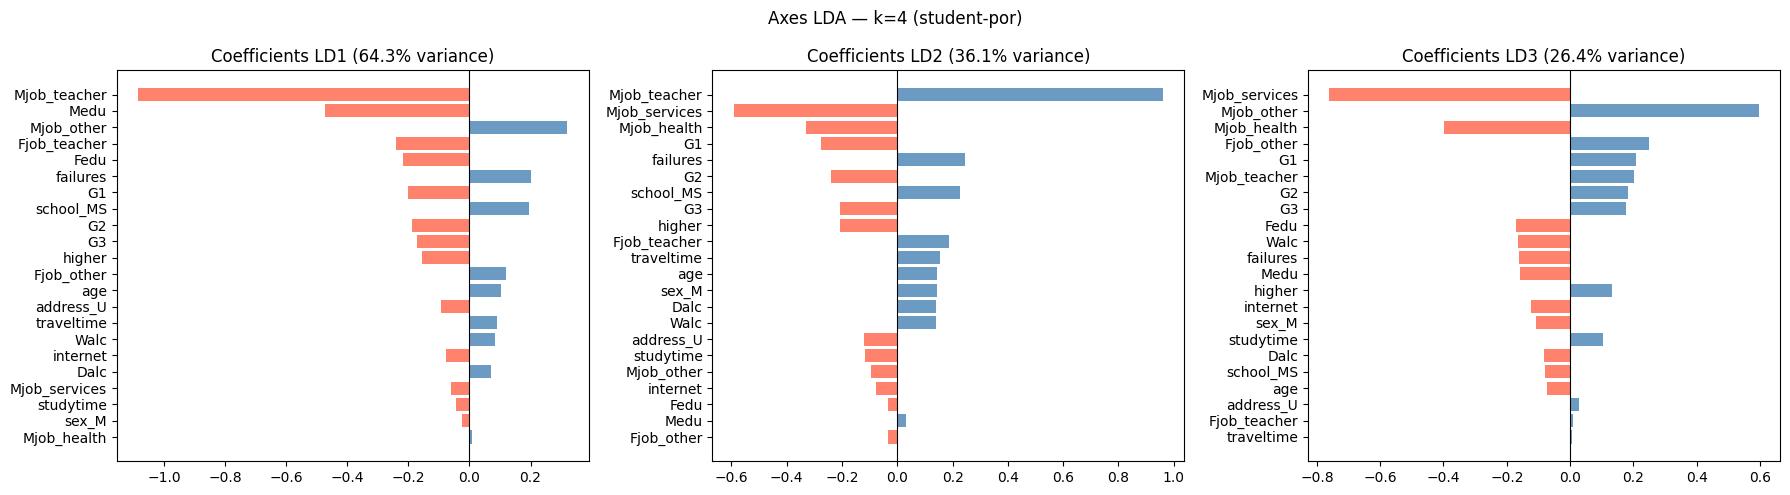

In [15]:
lda4 = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
lda4_scores = cross_val_score(lda4, X4, y4, cv=cv, scoring='accuracy')
lda4.fit(X4, y4)
var4 = lda4.explained_variance_ratio_

qda4 = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda4_scores = cross_val_score(qda4, X4, y4, cv=cv, scoring='accuracy')
qda4.fit(X4, y4)

print(f"LDA (shrinkage='auto') : {lda4_scores.mean():.3f} ± {lda4_scores.std():.3f}")
print(f"QDA (reg_param=0.1)   : {qda4_scores.mean():.3f} ± {qda4_scores.std():.3f}")
print(f"Variance LDA : " + "  ".join(f"LD{i+1}={v*100:.1f}%" for i, v in enumerate(var4)))

coef4 = pd.DataFrame(lda4.scalings_[:, :3], index=top4, columns=['LD1', 'LD2', 'LD3'])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    col = f'LD{i+1}'
    data = coef4[col].sort_values(key=abs, ascending=True)
    colors = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coefficients {col} ({var4[i]*100:.1f}% variance)')
plt.suptitle('Axes LDA — k=4 (student-por)', fontsize=12)
plt.tight_layout(); plt.show()


### 6. Comparaison + matrices de confusion

=== Comparaison k=4 (por) ===
Naïf                  : 0.347
KNN (k=12)          : 0.909 ± 0.029
LDA (shrinkage='auto'): 0.906 ± 0.022
QDA (reg_param=0.1)   : 0.872 ± 0.033


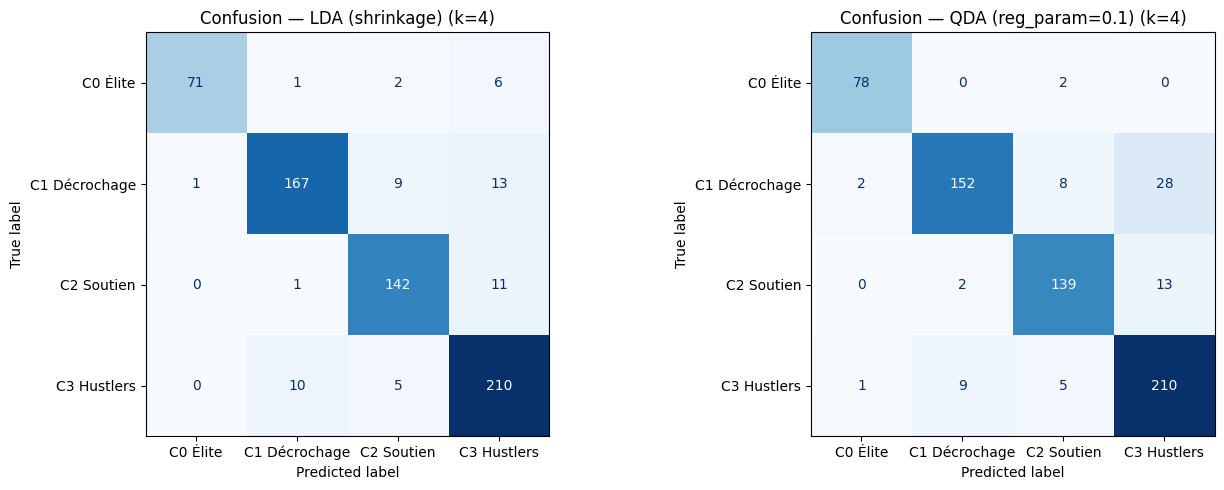

In [16]:
knn4_scores = cross_val_score(KNeighborsClassifier(n_neighbors=best_k4), X4, y4, cv=cv, scoring='accuracy')
labels_short4 = ['C0 Élite', 'C1 Décrochage', 'C2 Soutien', 'C3 Hustlers']

print("=== Comparaison k=4 (por) ===")
print(f"Naïf                  : {naive4:.3f}")
print(f"KNN (k={best_k4:2d})          : {knn4_scores.mean():.3f} ± {knn4_scores.std():.3f}")
print(f"LDA (shrinkage='auto'): {lda4_scores.mean():.3f} ± {lda4_scores.std():.3f}")
print(f"QDA (reg_param=0.1)   : {qda4_scores.mean():.3f} ± {qda4_scores.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model, title) in zip(axes, [(lda4, 'LDA (shrinkage)'), (qda4, 'QDA (reg_param=0.1)')]):
    cm = confusion_matrix(y4, model.predict(X4))
    ConfusionMatrixDisplay(cm, display_labels=labels_short4).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — {title} (k=4)')
plt.tight_layout(); plt.show()


### 7. Projection LDA

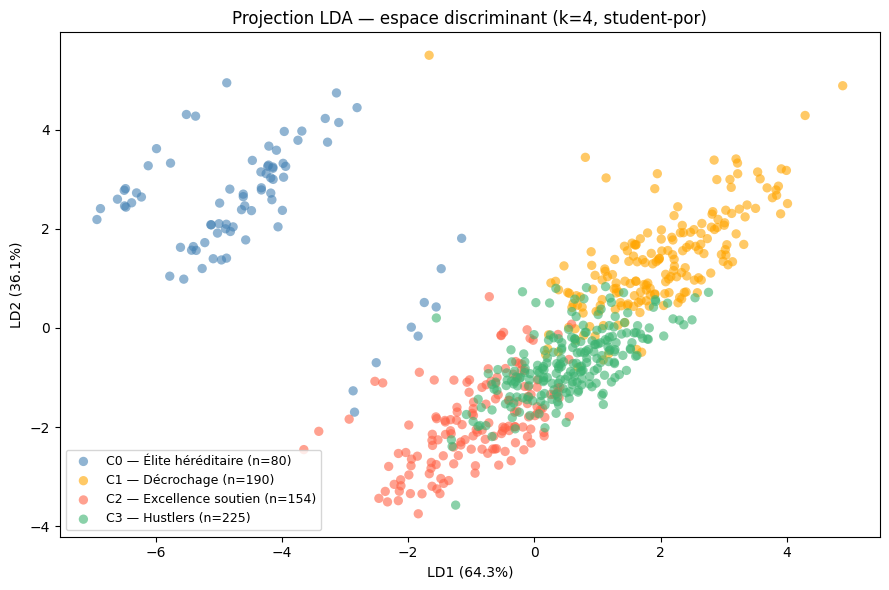

In [17]:
X4_lda  = lda4.transform(X4)
palette = ['steelblue', 'orange', 'tomato', 'mediumseagreen']
names4  = ['Élite héréditaire', 'Décrochage', 'Excellence soutien', 'Hustlers']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(4):
    mask = y4 == c
    ax.scatter(X4_lda[mask, 0], X4_lda[mask, 1],
               c=palette[c], label=f'C{c} — {names4[c]} (n={mask.sum()})',
               alpha=0.6, s=45, edgecolors='none')
ax.set_xlabel(f'LD1 ({var4[0]*100:.1f}%)')
ax.set_ylabel(f'LD2 ({var4[1]*100:.1f}%)')
ax.set_title('Projection LDA — espace discriminant (k=4, student-por)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


---
## Bilan — student-por vs student-mat

| | por k=3 | por k=4 | mat k=3 |
|---|---|---|---|
| Clusters | 202/250/197 | 80/190/154/225 | 152/155/88 |
| Naïf | 38.5% | 34.7% | 39.2% |
| KNN | ~87.8% | ~90.9% | ~85.3% |
| LDA | ~92.8% | ~90.6% | ~89.1% |
| QDA | ~87.2% | ~87.2% | ~85.6% |

**LDA domine sur k=3** (por et mat) — les 3 classes sont bien séparées linéairement.
**KNN et LDA sont proches sur k=4** — la subdivision de l'Excellence crée deux clusters
(Élite vs Soutien) que LDA sépare moins facilement car leurs frontières ne sont pas linéaires.